# ISL1 deconvolution with GSE202398 and eLife Figure 4 markers

This notebook rebuilds the GSE202398 single-cell reference from the GEO tarball only. It does not use the GEO sample-description xlsx. Sample/day labels are inferred from the HTO feature names inside the 10x H5 files.

After Leiden clustering, the notebook uses the top marker genes from `elife-80075-fig4-data2-v2.xlsx` to inspect the generated clusters, assign broad eLife-style labels, and then use those labels for MuSiC deconvolution of the ISL1 bulk RNA-seq data.


## Setup

Inputs:
- GEO tarball: `GSE202398_RAW.tar`
- eLife Figure 4-source data 2 marker table: `elife-80075-fig4-data2-v2.xlsx`
- ISL1 bulk counts from the March 2026 NW DRACC-processed tables

Outputs are written under `MorPhiC/publication/ISL1_GSE202398_deconvolution` as PNG, TSV, and RDS files.


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(Matrix)
  library(Seurat)
  library(SingleCellExperiment)
  library(readxl)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(stringr)
  library(ggplot2)
  library(RColorBrewer)
})

theme_set(theme_classic(base_size = 13))
set.seed(202398)

personal_path <- "/fh/working/sun_w/sshen/MorPhiC"
bulk_data_path <- "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/DRACC-processed/NW_exchange_experiment_DRACC_processed_March2026/Tables"
gene_anno_path <- "/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv"

gse_dir <- file.path(personal_path, "public_data", "GSE202398")
h5_dir <- file.path(gse_dir, "h5")
figure_dir <- file.path(personal_path, "publication", "ISL1_GSE202398_deconvolution")

dir.create(gse_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(h5_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)

raw_tar <- file.path(gse_dir, "GSE202398_RAW.tar")
fig4_marker_path <- file.path(gse_dir, "elife-80075-fig4-data2-v2.xlsx")


In [2]:
required_packages <- c(
  "data.table", "Matrix", "Seurat", "SingleCellExperiment", "readxl",
  "dplyr", "tidyr", "tibble", "stringr", "ggplot2", "RColorBrewer", "leidenbase"
)
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) {
  stop("Missing required packages: ", paste(missing_packages, collapse = ", "))
}

mnn_packages <- c("SeuratWrappers", "batchelor")
missing_mnn_packages <- mnn_packages[!vapply(mnn_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_mnn_packages) > 0) {
  message("FastMNN packages are missing: ", paste(missing_mnn_packages, collapse = ", "))
  message("Run the optional FastMNN install cell before the integration section.")
} else {
  message("FastMNN packages are available.")
}

if (!requireNamespace("MuSiC", quietly = TRUE)) {
  message("MuSiC is not installed. Run the install cell below once before the deconvolution section.")
} else {
  message("MuSiC is available.")
}


FastMNN packages are available.

MuSiC is available.



In [3]:
geo_raw_url <- "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE202nnn/GSE202398/suppl/GSE202398_RAW.tar"
fig4_marker_url <- "https://cdn.elifesciences.org/articles/80075/elife-80075-fig4-data2-v2.xlsx"

download_if_missing <- function(url, destfile) {
  if (!file.exists(destfile)) {
    message("Downloading ", basename(destfile))
    download.file(url, destfile = destfile, mode = "wb", quiet = FALSE)
  } else {
    message("Already present: ", destfile)
  }
}

download_if_missing(geo_raw_url, raw_tar)
download_if_missing(fig4_marker_url, fig4_marker_path)

filtered_h5 <- list.files(h5_dir, pattern = "filtered_feature_bc_matrix[.]h5$", full.names = TRUE)
if (length(filtered_h5) < 3) {
  message("Extracting ", raw_tar, " to ", h5_dir)
  utils::untar(raw_tar, exdir = h5_dir)
}

h5_files <- list.files(h5_dir, pattern = "feature_bc_matrix[.]h5$", full.names = TRUE)
data.frame(
  file = basename(h5_files),
  size_mb = round(file.info(h5_files)$size / 1024^2, 1),
  stringsAsFactors = FALSE
)


Already present: /fh/working/sun_w/sshen/MorPhiC/public_data/GSE202398/GSE202398_RAW.tar



Already present: /fh/working/sun_w/sshen/MorPhiC/public_data/GSE202398/elife-80075-fig4-data2-v2.xlsx



file,size_mb
<chr>,<dbl>
GSM6118768_Galdos_Seq_Run1_filtered_feature_bc_matrix.h5,93.1
GSM6118768_Galdos_Seq_Run1_raw_feature_bc_matrix.h5,162.0
GSM6118769_Galdos_Seq_Run2_filtered_feature_bc_matrix.h5,97.6
GSM6118769_Galdos_Seq_Run2_raw_feature_bc_matrix.h5,153.6
GSM6118770_Galdos_Seq_Run3_filtered_feature_bc_matrix.h5,73.6
GSM6118770_Galdos_Seq_Run3_raw_feature_bc_matrix.h5,133.9


## Read filtered H5 files and infer sample labels from HTO features

The active hashtags are inferred per run from HTO total counts. This keeps all 12 HTO tags for Run1 and the six active tags for Run2 and Run3, without needing the sample-description spreadsheet.


In [4]:
filtered_h5_files <- sort(list.files(h5_dir, pattern = "filtered_feature_bc_matrix[.]h5$", full.names = TRUE))
filtered_h5_files

run_from_file <- function(h5_file) {
  str_extract(basename(h5_file), "Run[0-9]+")
}

parse_hto_meta <- function(hto_feature, run_id) {
  # Seurat replaces underscores in feature names with dashes, so normalize back to underscores.
  hto_feature_raw <- as.character(hto_feature)
  hto_feature_clean <- str_replace_all(hto_feature_raw, "-", "_")

  valid <- str_detect(hto_feature_clean, "^(WTC|LMNA)_DAY[0-9]+$")
  line_raw <- str_extract(hto_feature_clean, "^[^_]+")
  day_raw <- str_extract(hto_feature_clean, "DAY[0-9]+")

  line <- ifelse(line_raw == "LMNA", "SCVI111", line_raw)
  day <- ifelse(!is.na(day_raw), str_replace(day_raw, "DAY", "Day"), NA_character_)

  data.frame(
    run = run_id,
    hto_feature_raw = hto_feature_raw,
    hto_feature = hto_feature_clean,
    line = ifelse(valid, line, NA_character_),
    day = ifelse(valid, day, NA_character_),
    sample_id = ifelse(valid, paste(run_id, hto_feature_clean, sep = "_"), NA_character_),
    stringsAsFactors = FALSE
  )
}

infer_active_hto_features <- function(hto_counts, relative_cutoff = 0.01) {
  totals <- Matrix::rowSums(hto_counts)
  totals <- sort(totals, decreasing = TRUE)
  active <- names(totals)[totals >= max(totals) * relative_cutoff]
  list(active = active, totals = totals)
}


[1] "/fh/working/sun_w/sshen/MorPhiC/public_data/GSE202398/h5/GSM6118768_Galdos_Seq_Run1_filtered_feature_bc_matrix.h5"
[2] "/fh/working/sun_w/sshen/MorPhiC/public_data/GSE202398/h5/GSM6118769_Galdos_Seq_Run2_filtered_feature_bc_matrix.h5"
[3] "/fh/working/sun_w/sshen/MorPhiC/public_data/GSE202398/h5/GSM6118770_Galdos_Seq_Run3_filtered_feature_bc_matrix.h5"

In [5]:
read_gse202398_run <- function(h5_file, min_features = 200, hto_relative_cutoff = 0.01, hto_positive_quantile = 0.99) {
  run_id <- run_from_file(h5_file)
  message("Reading ", run_id, ": ", basename(h5_file))

  mats <- Read10X_h5(h5_file)
  if (is.list(mats)) {
    rna_counts <- mats[["Gene Expression"]]
    hto_counts <- mats[["Antibody Capture"]]
  } else {
    rna_counts <- mats
    hto_counts <- NULL
  }

  so <- CreateSeuratObject(
    counts = rna_counts,
    project = run_id,
    min.cells = 3,
    min.features = min_features
  )
  so$run <- run_id

  if (!is.null(hto_counts)) {
    inferred <- infer_active_hto_features(hto_counts, relative_cutoff = hto_relative_cutoff)
    active_hto <- inferred$active
    hto_totals <- data.frame(
      run = run_id,
      hto_feature = names(inferred$totals),
      total_counts = as.numeric(inferred$totals),
      active = names(inferred$totals) %in% active_hto,
      stringsAsFactors = FALSE
    )
    so@misc$active_hto_table <- hto_totals

    message(run_id, " active HTO features: ", paste(active_hto, collapse = ", "))
    hto_counts <- hto_counts[active_hto, colnames(so), drop = FALSE]

    so[["HTO"]] <- CreateAssayObject(counts = hto_counts)
    so <- NormalizeData(
      so,
      assay = "HTO",
      normalization.method = "CLR",
      margin = 2,
      verbose = FALSE
    )
    so <- HTODemux(so, assay = "HTO", positive.quantile = hto_positive_quantile)

    hto_meta <- parse_hto_meta(as.character(so$hash.ID), run_id = run_id)
    so$hto_feature <- hto_meta$hto_feature
    so$line <- hto_meta$line
    so$day <- hto_meta$day
    so$sample_id <- hto_meta$sample_id

    before_n <- ncol(so)
    so <- subset(so, subset = HTO_classification.global == "Singlet" & !is.na(sample_id))
    message(run_id, ": kept ", ncol(so), " singlets from ", before_n, " filtered cells")

    DefaultAssay(so) <- "RNA"
    so[["HTO"]] <- NULL
  } else {
    warning("No Antibody Capture assay found in ", basename(h5_file), "; using run as sample_id.")
    so$hto_feature <- NA_character_
    so$line <- NA_character_
    so$day <- NA_character_
    so$sample_id <- run_id
  }

  so
}

sc_list <- lapply(filtered_h5_files, read_gse202398_run)
names(sc_list) <- vapply(filtered_h5_files, run_from_file, character(1))

hto_active_table <- bind_rows(lapply(sc_list, function(x) x@misc$active_hto_table))
hto_active_table


Reading Run1: GSM6118768_Galdos_Seq_Run1_filtered_feature_bc_matrix.h5

Genome matrix has multiple modalities, returning a list of matrices for this genome

Run1 active HTO features: LMNA_DAY1, WTC_DAY2, LMNA_DAY2, LMNA_DAY5, LMNA_DAY6, WTC_DAY3, LMNA_DAY4, WTC_DAY4, LMNA_DAY3, WTC_DAY5, WTC_DAY1, WTC_DAY6

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `ident` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.
Cutoff for LMNA-DAY1 : 166 reads

Cutoff for WTC-DAY2 : 272 reads

Cutoff for LMNA-DAY2 : 292 reads

Cutoff for LMNA-DAY5 : 423 reads

Cutoff for LMNA-DAY6 : 269 reads

Cutoff for WTC-DAY3 : 613 reads

Cutoff for LMNA-DAY4 : 289 

run,hto_feature,total_counts,active
<chr>,<chr>,<dbl>,<lgl>
Run1,LMNA_DAY1,11920564,TRUE
Run1,WTC_DAY2,8804995,TRUE
Run1,LMNA_DAY2,8565575,TRUE
Run1,LMNA_DAY5,7869849,TRUE
Run1,LMNA_DAY6,7772346,TRUE
Run1,WTC_DAY3,7495621,TRUE
Run1,LMNA_DAY4,7008312,TRUE
Run1,WTC_DAY4,6898671,TRUE
Run1,LMNA_DAY3,6540486,TRUE


In [6]:
sc_ref <- merge(
  x = sc_list[[1]],
  y = sc_list[-1],
  add.cell.ids = names(sc_list),
  project = "GSE202398"
)

# Keep the inferred metadata ordered for plotting and summaries.
day_levels <- paste0("Day", c(0:7, 11, 13, 15, 30))
line_levels <- c("WTC", "SCVI111")

sc_ref$run <- factor(sc_ref$run, levels = names(sc_list))
sc_ref$day <- factor(as.character(sc_ref$day), levels = day_levels)
sc_ref$line <- factor(as.character(sc_ref$line), levels = line_levels)
sc_ref$hto_feature <- as.character(sc_ref$hto_feature)

# sample_id remains run-specific for MuSiC because the same HTO/day can appear in multiple runs.
sc_ref$sample_id <- paste(sc_ref$run, sc_ref$hto_feature, sep = "_")

sample_count_table <- sc_ref@meta.data %>%
  as_tibble(rownames = "cell_barcode") %>%
  count(run, line, day, hto_feature, sample_id, name = "n_cells") %>%
  arrange(run, line, day)

sample_count_table


run,line,day,hto_feature,sample_id,n_cells
<fct>,<fct>,<fct>,<chr>,<chr>,<int>
Run1,WTC,Day1,WTC_DAY1,Run1_WTC_DAY1,1034
Run1,WTC,Day2,WTC_DAY2,Run1_WTC_DAY2,1172
Run1,WTC,Day3,WTC_DAY3,Run1_WTC_DAY3,1145
Run1,WTC,Day4,WTC_DAY4,Run1_WTC_DAY4,1245
Run1,WTC,Day5,WTC_DAY5,Run1_WTC_DAY5,856
Run1,WTC,Day6,WTC_DAY6,Run1_WTC_DAY6,926
Run1,SCVI111,Day1,LMNA_DAY1,Run1_LMNA_DAY1,865
Run1,SCVI111,Day2,LMNA_DAY2,Run1_LMNA_DAY2,943
Run1,SCVI111,Day3,LMNA_DAY3,Run1_LMNA_DAY3,875


## QC, FastMNN integration, UMAP, and Leiden clustering

This follows the paper's workflow more closely: QC first, then normalize each run with Seurat defaults, choose shared integration features with `SelectIntegrationFeatures`, remove cell-cycle genes from the integration feature set, run mutual nearest-neighbor batch correction with `RunFastMNN`, and use 15 MNN dimensions for neighbors, UMAP, and Leiden clustering.


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
QC kept 31561 cells from 34778.



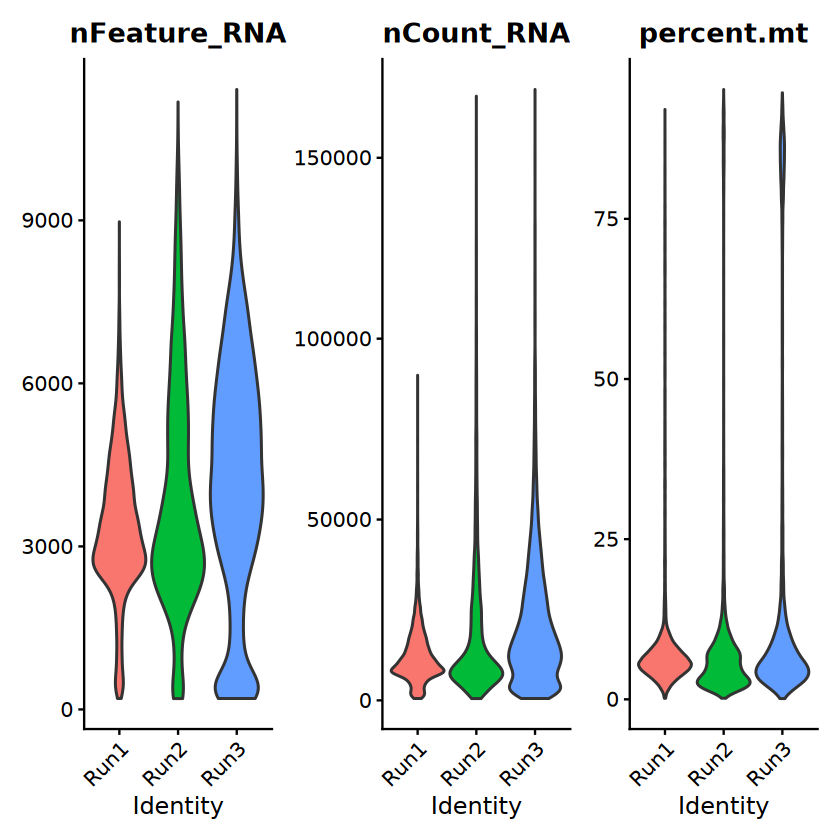

In [7]:
sc_ref[["percent.mt"]] <- PercentageFeatureSet(sc_ref, pattern = "^MT-")

p_qc <- VlnPlot(
  sc_ref,
  features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
  group.by = "run",
  ncol = 3,
  pt.size = 0
)
print(p_qc)

qc_before <- ncol(sc_ref)
sc_ref <- subset(
  sc_ref,
  subset = nFeature_RNA >= 500 & nFeature_RNA <= 10000 & percent.mt <= 20
)
message("QC kept ", ncol(sc_ref), " cells from ", qc_before, ".")


Integration features before cell-cycle filtering: 3000

Integration features after cell-cycle filtering: 2918

Warning message:
“Layer ‘scale.data’ is empty”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message in RunLeiden(object = object, leiden_method = leiden_method, leiden_objective_function = leiden_objective_function, :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


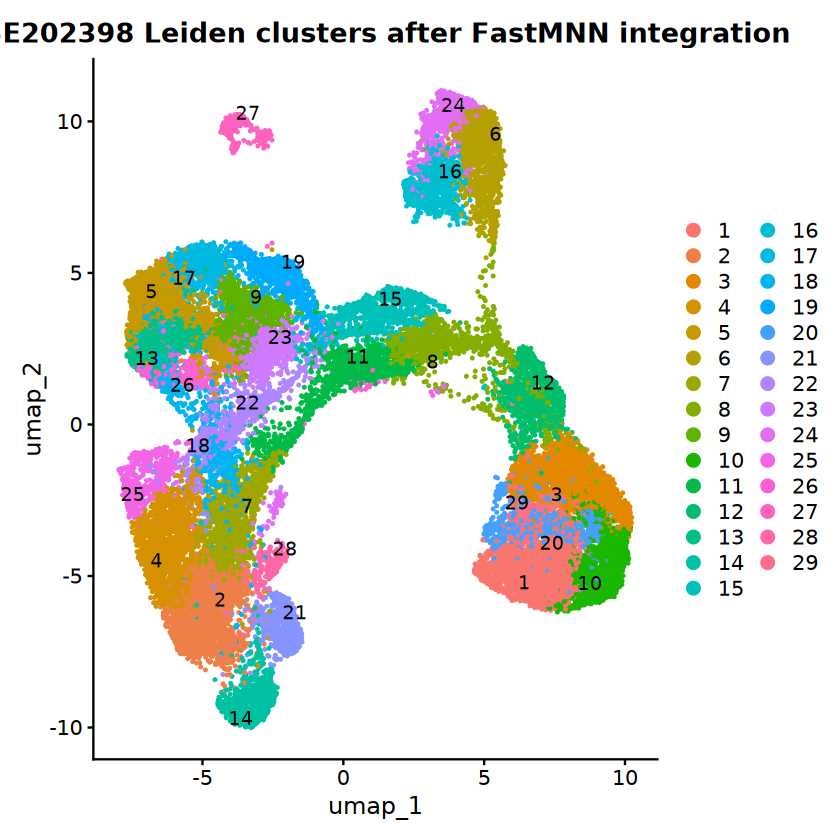

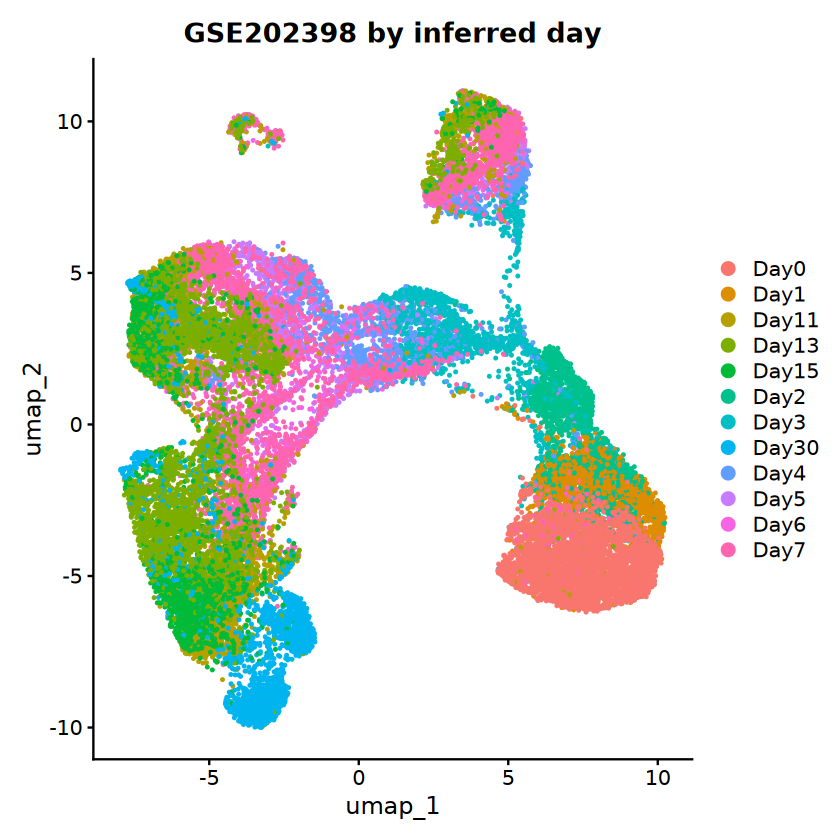

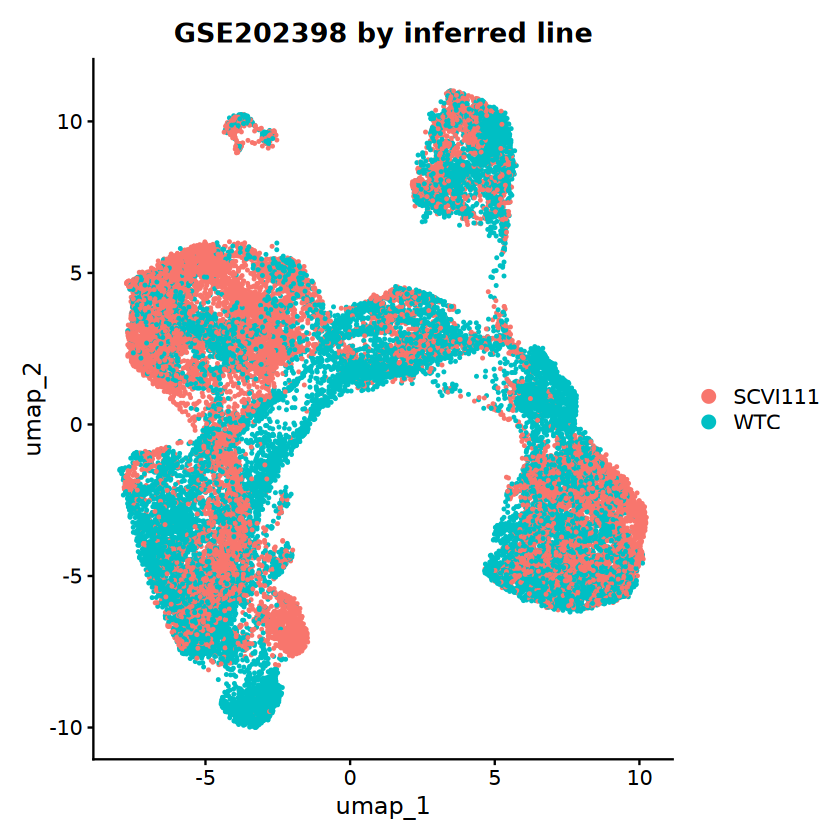

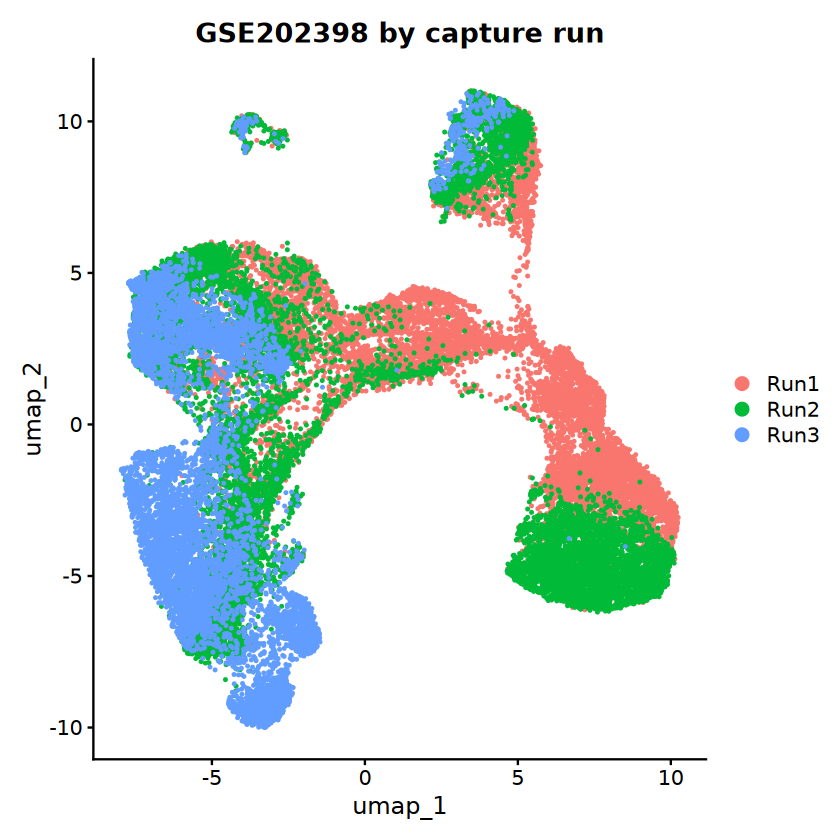

In [8]:
if (!requireNamespace("SeuratWrappers", quietly = TRUE) || !requireNamespace("batchelor", quietly = TRUE)) {
  stop(
    "FastMNN integration requires SeuratWrappers and batchelor. ",
    "Run the optional FastMNN install cell, restart the R kernel, and rerun."
  )
}

DefaultAssay(sc_ref) <- "RNA"

# Normalize and find variable genes separately per capture run.
sc_list_mnn <- SplitObject(sc_ref, split.by = "run")
sc_list_mnn <- lapply(sc_list_mnn, function(obj) {
  obj <- NormalizeData(obj, verbose = FALSE)
  obj <- FindVariableFeatures(obj, selection.method = "vst", nfeatures = 3000, verbose = FALSE)
  obj
})

# Paper-style shared integration feature selection.
integration_features <- SelectIntegrationFeatures(
  object.list = sc_list_mnn,
  nfeatures = 3000
)

cell_cycle_genes <- unique(c(cc.genes.updated.2019$s.genes, cc.genes.updated.2019$g2m.genes))
integration_features_no_cc <- setdiff(integration_features, cell_cycle_genes)

message("Integration features before cell-cycle filtering: ", length(integration_features))
message("Integration features after cell-cycle filtering: ", length(integration_features_no_cc))

# Mutual nearest-neighbor integration across the three runs.
sc_ref <- SeuratWrappers::RunFastMNN(
  object.list = sc_list_mnn,
  features = integration_features_no_cc,
  reduction.name = "mnn",
  reduction.key = "MNN_",
  verbose = TRUE
)

DefaultAssay(sc_ref) <- "RNA"

mnn_dims <- 1:15

# ElbowPlot may or may not be informative for the MNN reduction, but this mirrors the paper check.
p_elbow_mnn <- try(ElbowPlot(sc_ref, reduction = "mnn", ndims = 30), silent = TRUE)
if (!inherits(p_elbow_mnn, "try-error")) {
  print(p_elbow_mnn)
}

sc_ref <- FindNeighbors(sc_ref, reduction = "mnn", dims = mnn_dims, verbose = FALSE)
sc_ref <- FindClusters(sc_ref, resolution = 1.5, algorithm = 4, verbose = FALSE)
sc_ref$leiden_clusters <- sc_ref$seurat_clusters
sc_ref <- RunUMAP(sc_ref, reduction = "mnn", dims = mnn_dims, verbose = FALSE)

p_umap_cluster <- DimPlot(sc_ref, reduction = "umap", group.by = "leiden_clusters", label = TRUE, repel = TRUE, pt.size = 0.2) +
  ggtitle("GSE202398 Leiden clusters after FastMNN integration")
p_umap_day <- DimPlot(sc_ref, reduction = "umap", group.by = "day", pt.size = 0.2) + ggtitle("GSE202398 by inferred day")
p_umap_line <- DimPlot(sc_ref, reduction = "umap", group.by = "line", pt.size = 0.2) + ggtitle("GSE202398 by inferred line")
p_umap_run <- DimPlot(sc_ref, reduction = "umap", group.by = "run", pt.size = 0.2) + ggtitle("GSE202398 by capture run")

print(p_umap_cluster)
print(p_umap_day)
print(p_umap_line)
print(p_umap_run)


## Use eLife Figure 4 markers to inspect generated Leiden clusters

The eLife marker table is not a per-cell annotation file. It is a marker/DE table for the annotated cell populations from the paper. Here we take the top marker genes per eLife cell type and ask which generated Leiden clusters express those marker sets.


In [9]:
fig4_markers_raw <- readxl::read_excel(fig4_marker_path, sheet = 1, .name_repair = "unique")
gene_cols <- grep("^gene", names(fig4_markers_raw), value = TRUE)
gene_col <- gene_cols[length(gene_cols)]

fig4_markers <- fig4_markers_raw %>%
  transmute(
    elife_cell_type = cluster,
    gene = as.character(.data[[gene_col]]),
    avg_log2FC = as.numeric(avg_log2FC),
    pct.1 = as.numeric(pct.1),
    pct.2 = as.numeric(pct.2),
    p_val_adj = as.numeric(p_val_adj)
  ) %>%
  filter(!is.na(elife_cell_type), !is.na(gene), gene != "")

cell_type_levels <- unique(fig4_markers$elife_cell_type)

fig4_marker_summary <- fig4_markers %>%
  count(elife_cell_type, sort = FALSE) %>%
  mutate(elife_cell_type = factor(elife_cell_type, levels = cell_type_levels)) %>%
  arrange(elife_cell_type)
fig4_marker_summary


New names:
• `gene` -> `gene...1`
• `gene` -> `gene...7`


elife_cell_type,n
<fct>,<int>
Early Primitive Streak,961
Epicardial Progenitors,629
Hepatic Endoderm,519
Definitive Endoderm,540
Early Cardiac Progenitors,382
Late Primitive Streak,508
Mesodermal Progenitors,474
Pluripotent Stem Cells,1115
Epicardial Cells,797


In [10]:
top_n_markers <- 8

fig4_top_markers <- fig4_markers %>%
  filter(gene %in% rownames(sc_ref)) %>%
  mutate(
    pct_specificity = pct.1 - pct.2
  ) %>%
  # Apply your specific thresholds
  filter(
    p_val_adj < 0.01,
    pct_specificity > 0.4
  ) %>%
  # Sort by cell type, then strictly by highest avg_log2FC
  arrange(elife_cell_type, desc(avg_log2FC)) %>%
  group_by(elife_cell_type) %>%
  slice_head(n = top_n_markers) %>%
  ungroup()

# Generate the summary output just like before
fig4_top_markers %>%
  group_by(elife_cell_type) %>%
  summarize(
    top_genes = paste(gene, collapse = ", "),
    mean_pct_specificity = mean(pct_specificity, na.rm = TRUE),
    .groups = "drop"
  )


elife_cell_type,top_genes,mean_pct_specificity
<chr>,<chr>,<dbl>
Definitive Endoderm,"LINC01356, PCAT14, FAM184A, APOC1, EPCAM, LINC00261, CCKBR, SOX17",0.6377500
Early Cardiac Progenitors,"HAS2, LIX1, PDGFRA, HAPLN1, TMEM88, BMPER, IRX3",0.4521429
Early Cardiomyocytes,"NPPA, MYH6, ACTA1, MYL7, EMC10, MYL3, TNNC1, AC020909.2",0.6462500
Early Primitive Streak,"MIXL1, TUBB2B, GAL, TUBB2A, POU5F1, NODAL, LINC01356, DPPA4",0.6611250
Endothelial Cells,"GNG11, RAMP2, SOST, TFPI2, KDR, TFPI, HAPLN1, CRHBP",0.6831250
Epicardial Cells,"COL3A1, COL1A1, COL1A2, COL14A1, CCDC80, FLRT2, TBX18, IGF2",0.4925000
Epicardial Progenitors,"IGF2, COL3A1, TMEM88, LUM, IGFBP3, HAND1, COL1A1, COL1A2",0.5248750
Hepatic Endoderm,"TTR, APOA1, APOA2, LINC00261, PCAT14, DLK1, EPCAM, VTN",0.6568750
Late Cardiac Progenitors,"ACTA2, MEF2C, MYH6, DGKI, CMYA5, JAG1, ACTC1, MYOCD",0.4967500


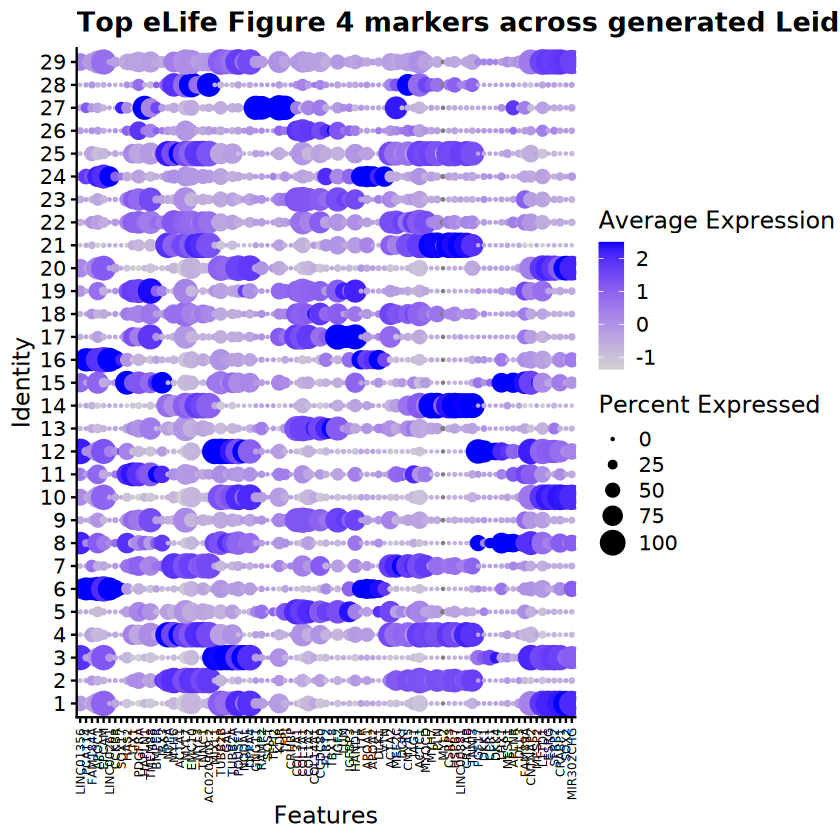

In [11]:
genes_for_dotplot <- unique(fig4_top_markers$gene)

p_dot <- DotPlot(sc_ref, features = genes_for_dotplot, group.by = "leiden_clusters") +
  RotatedAxis() +
  theme(axis.text.x = element_text(size = 7, angle = 90, hjust = 1, vjust = 0.5)) +
  ggtitle("Top eLife Figure 4 markers across generated Leiden clusters")
print(p_dot)


In [12]:
get_average_expression <- function(seurat_obj, group.by) {
  tryCatch(
    AverageExpression(seurat_obj, assays = "RNA", group.by = group.by, layer = "data")$RNA,
    error = function(e) AverageExpression(seurat_obj, assays = "RNA", group.by = group.by, slot = "data")$RNA
  )
}

avg_expr_by_cluster <- get_average_expression(sc_ref, group.by = "leiden_clusters")

# Seurat may rename numeric groups from "0" to "g0" in AverageExpression output.
colnames(avg_expr_by_cluster) <- sub("^g([0-9]+)$", "\\1", colnames(avg_expr_by_cluster))

markers_by_type <- split(fig4_top_markers$gene, fig4_top_markers$elife_cell_type)

cluster_marker_scores <- bind_rows(lapply(names(markers_by_type), function(cell_type) {
  genes <- intersect(markers_by_type[[cell_type]], rownames(avg_expr_by_cluster))
  if (length(genes) == 0) {
    return(NULL)
  }

  tibble(
    elife_cell_type = cell_type,
    leiden_cluster = colnames(avg_expr_by_cluster),
    n_marker_genes = length(genes),
    mean_top8_expression = as.numeric(colMeans(avg_expr_by_cluster[genes, , drop = FALSE]))
  )
}))

cluster_labels <- cluster_marker_scores %>%
  group_by(leiden_cluster) %>%
  slice_max(mean_top8_expression, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  transmute(
    leiden_cluster = as.character(leiden_cluster),
    cell_type_music = as.character(elife_cell_type),
    n_marker_genes,
    mean_top8_expression
  )

all_clusters <- unique(as.character(sc_ref$leiden_clusters))
missing_clusters <- setdiff(all_clusters, cluster_labels$leiden_cluster)
if (length(missing_clusters) > 0) {
  stop("Missing cell-type labels for Leiden clusters: ", paste(missing_clusters, collapse = ", "))
}

label_vec <- setNames(cluster_labels$cell_type_music, cluster_labels$leiden_cluster)
sc_ref$cell_type_music <- unname(label_vec[as.character(sc_ref$leiden_clusters)])
sc_ref$cell_type_music <- factor(sc_ref$cell_type_music, levels = cell_type_levels)

if (anyNA(sc_ref$cell_type_music)) {
  stop("cell_type_music still contains NA values after marker assignment.")
}

cluster_labels %>%
  mutate(leiden_cluster_num = suppressWarnings(as.numeric(leiden_cluster))) %>%
  arrange(leiden_cluster_num, leiden_cluster) %>%
  select(-leiden_cluster_num)


leiden_cluster,cell_type_music,n_marker_genes,mean_top8_expression
<chr>,<chr>,<int>,<dbl>
1,Pluripotent Stem Cells,8,1.867378
2,Early Cardiomyocytes,8,2.995034
3,Early Primitive Streak,8,2.064524
4,Early Cardiomyocytes,8,3.361349
5,Epicardial Progenitors,8,1.489823
6,Hepatic Endoderm,8,1.302796
7,Early Cardiomyocytes,8,2.406863
8,Early Primitive Streak,8,1.145393
9,Epicardial Progenitors,8,1.496682


    
     Early Primitive Streak Epicardial Progenitors Hepatic Endoderm
  1                       0                      0                0
  2                       0                      0                0
  3                    2016                      0                0
  4                       0                      0                0
  5                       0                   1673                0
  6                       0                      0             1590
  7                       0                      0                0
  8                    1273                      0                0
  9                       0                   1245                0
  10                      0                      0                0
  11                      0                      0                0
  12                   1138                      0                0
  13                      0                      0                0
  14                      0                

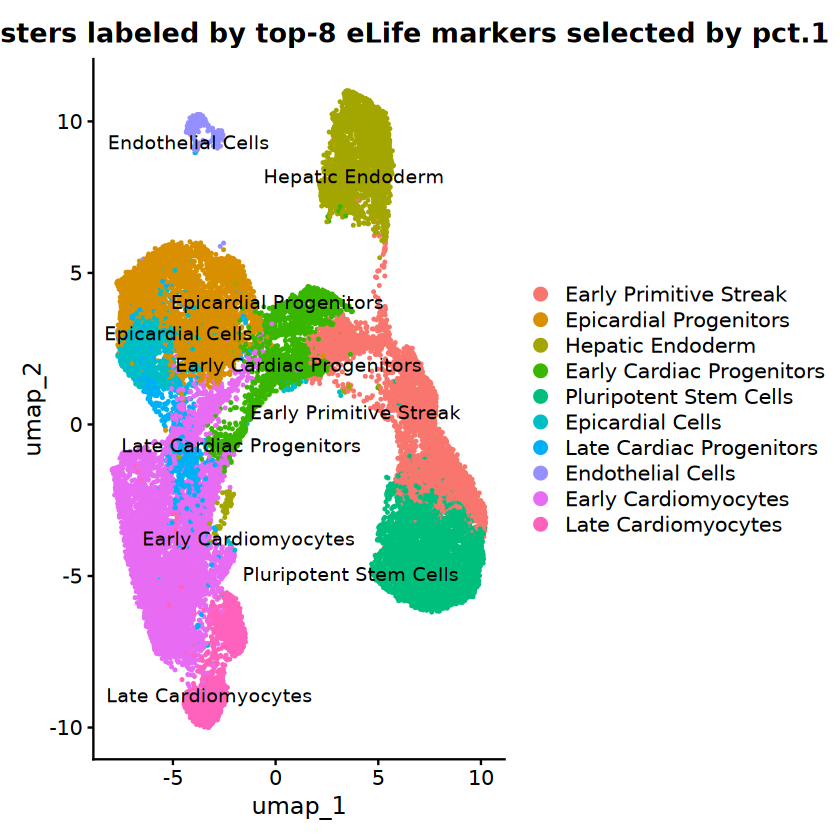

In [13]:
p_umap_type <- DimPlot(
  sc_ref,
  reduction = "umap",
  group.by = "cell_type_music",
  label = TRUE,
  repel = TRUE,
  pt.size = 0.2
) + ggtitle("GSE202398 Leiden clusters labeled by top-8 eLife markers selected by pct.1 - pct.2")
print(p_umap_type)

table(sc_ref$leiden_clusters, sc_ref$cell_type_music)


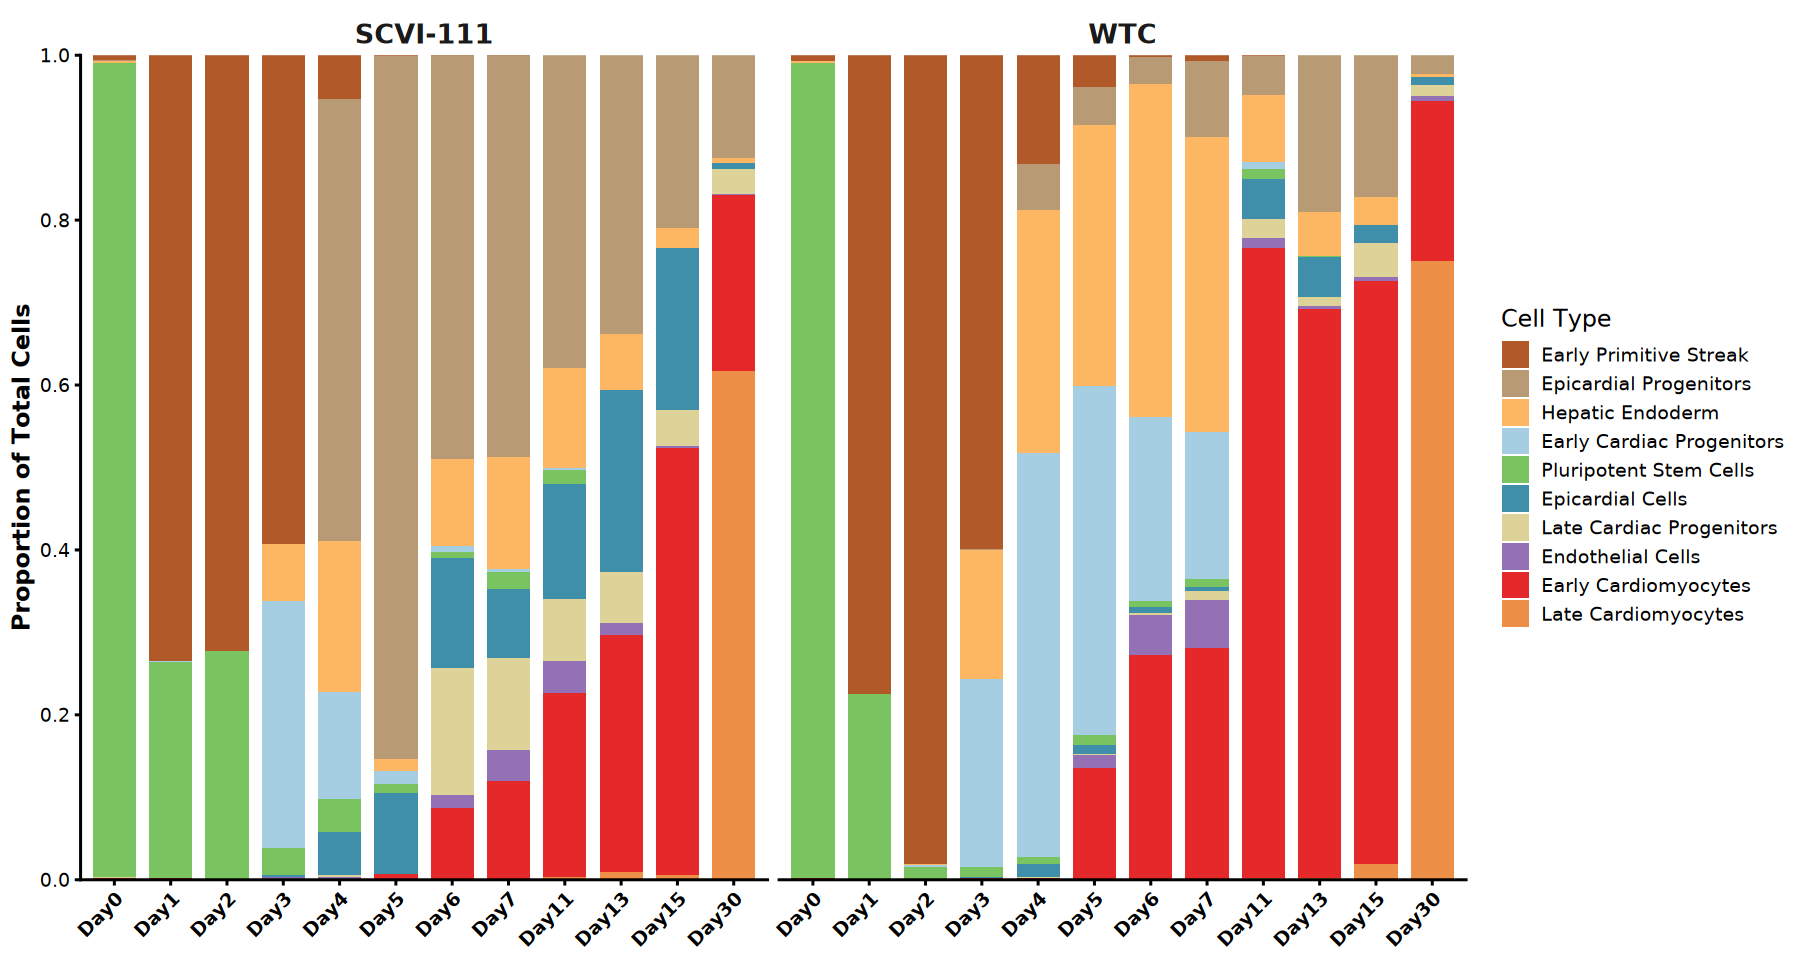

In [14]:
library(dplyr)
library(ggplot2)

day_levels <- paste0("Day", c(0:7, 11, 13, 15, 30))

prop_df <- sc_ref@meta.data %>%
  as_tibble(rownames = "cell_barcode") %>%
  filter(!is.na(line), !is.na(day), !is.na(cell_type_music)) %>%
  mutate(
    day = factor(as.character(day), levels = day_levels),
    line_plot = recode(as.character(line), "SCVI111" = "SCVI-111", "WTC" = "WTC")
  ) %>%
  count(line_plot, day, cell_type_music, name = "n_cells") %>%
  group_by(line_plot, day) %>%
  mutate(prop = n_cells / sum(n_cells)) %>%
  ungroup()

cell_types <- sort(unique(as.character(prop_df$cell_type_music)))
n_colors <- length(cell_types)

if (requireNamespace("Polychrome", quietly = TRUE)) {
  color_vec <- Polychrome::createPalette(
    n_colors,
    seedcolors = c("#000000", "#E69F00", "#56B4E9", "#009E73", "#CC79A7")
  )
} else {
  color_vec <- colorRampPalette(RColorBrewer::brewer.pal(12, "Paired"))(n_colors)
  set.seed(42)
  color_vec <- sample(color_vec)
}

names(color_vec) <- cell_types

options(repr.plot.width = 15, repr.plot.height = 8)

p <- ggplot(prop_df, aes(x = day, y = prop, fill = cell_type_music)) +
  geom_col(width = 0.75, color = NA) +
  facet_wrap(~ line_plot, nrow = 1) +
  scale_fill_manual(values = color_vec) +
  scale_y_continuous(
    limits = c(0, 1),
    breaks = seq(0, 1, 0.2),
    expand = c(0, 0)
  ) +
  labs(
    x = NULL,
    y = "Proportion of Total Cells",
    fill = "Cell Type"
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 16),
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.title.y = element_text(face = "bold"),
    legend.position = "right"
  )

print(p)


## Prepare ISL1 bulk RNA-seq counts

This follows the ISL1 bulk-count source from `04_Deconvolution_ISL1.Rmd`, maps Ensembl IDs to HGNC symbols, and collapses duplicate symbols so bulk genes match the GSE202398 gene symbols.


In [15]:
load_isl1_bulk <- function(personal_path, bulk_data_path, gene_anno_path) {
  meta <- fread(file.path(personal_path, "NW_meta_data.tsv"), data.table = FALSE)

  ko_conditions <- c(
    "NW_C39_AUXIN", "NW_C14_AUXIN",
    "JAX_CLONE_DO4", "JAX_CLONE_AD2",
    "MSK_CLONE_05", "MSK_CLONE_07",
    "UCSF_CLONE_D1_DOX", "UCSF_CLONE_B1 DOX"
  )
  meta$ko_gene <- ifelse(meta$Dcondition %in% ko_conditions, "ISL1_KO", "WT")

  cts <- fread(file.path(bulk_data_path, "genesCounts.csv"), data.table = FALSE)
  colnames(cts) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(cts))

  stopifnot(
    setequal(meta$Name, names(cts)[-1]),
    !any(duplicated(meta$Name)),
    !any(duplicated(names(cts)[-1]))
  )
  meta <- meta[match(names(cts)[-1], meta$Name), ]

  counts <- data.matrix(cts[, -1, drop = FALSE])
  rownames(counts) <- cts$Name

  gene_anno <- fread(gene_anno_path, data.table = FALSE)
  counts <- counts[rownames(counts) %in% gene_anno$ensembl_gene_id, , drop = FALSE]

  q75 <- apply(counts, 1, function(x) quantile(x, probs = 0.75, na.rm = TRUE))
  counts <- counts[q75 > 0, , drop = FALSE]

  symbols <- gene_anno$hgnc_symbol[match(rownames(counts), gene_anno$ensembl_gene_id)]
  missing_symbol <- is.na(symbols) | symbols == ""
  symbols[missing_symbol] <- rownames(counts)[missing_symbol]

  rownames(counts) <- symbols
  counts <- rowsum(counts, group = rownames(counts), reorder = FALSE)
  storage.mode(counts) <- "numeric"

  list(counts = counts, meta = meta)
}

bulk <- load_isl1_bulk(personal_path, bulk_data_path, gene_anno_path)
bulk_matrix <- as.matrix(bulk$counts)
bulk_meta <- bulk$meta

dim(bulk_matrix)
table(bulk_meta$Dcondition, bulk_meta$ko_gene)


[1] 23655    57

                    
                     ISL1_KO WT
  JAX_CLONE_AD2            3  0
  JAX_CLONE_DO4            3  0
  KOLF_PARENT_AUXIN        0  3
  KOLF_PARENT_DMSO         0  3
  KOLF_PARENT_NA           0  3
  MSK_CLONE_05             3  0
  MSK_CLONE_07             3  0
  NW_C14_AUXIN             3  0
  NW_C14_DMSO              0  3
  NW_C39_AUXIN             3  0
  NW_C39_DMSO              0  3
  NW_OSTIR_AUXIN           0  3
  NW_OSTIR_DMSO            0  3
  UCSF_AAVS1_DMSO          0  3
  UCSF_AAVS1_DOX           0  3
  UCSF_CLONE_B1 DMSO       0  3
  UCSF_CLONE_B1 DOX        3  0
  UCSF_CLONE_D1_DMSO       0  3
  UCSF_CLONE_D1_DOX        3  0

## Run MuSiC deconvolution with Day30 reference cells only

The full GSE202398 time course is used for integration, clustering, and marker-based annotation. For deconvolution, only Day30 single cells are passed to MuSiC as the reference.


In [16]:
if (!requireNamespace("MuSiC", quietly = TRUE)) {
  stop("MuSiC is not installed. Run remotes::install_github('xuranw/MuSiC') in the install cell above, then rerun this section.")
}
suppressPackageStartupMessages(library(MuSiC))

stopifnot("cell_type_music" %in% colnames(sc_ref@meta.data))
stopifnot("sample_id" %in% colnames(sc_ref@meta.data))

sc_ref_music <- subset(
  sc_ref,
  subset = day == "Day30" & !is.na(cell_type_music) & !is.na(sample_id)
)

if (ncol(sc_ref_music) == 0) {
  stop("No Day30 cells found in sc_ref_music. Check the inferred day labels.")
}

message("Day30 reference cells used for MuSiC: ", ncol(sc_ref_music))
print(table(sc_ref_music$line, sc_ref_music$cell_type_music))
print(table(sc_ref_music$sample_id))

sc_sce <- as.SingleCellExperiment(sc_ref_music, assay = "RNA")
colData(sc_sce)$cell_type_music <- sc_ref_music$cell_type_music
colData(sc_sce)$sample_id <- sc_ref_music$sample_id

common_genes <- intersect(rownames(bulk_matrix), rownames(sc_sce))
message("Common genes between ISL1 bulk and Day30 GSE202398 reference: ", length(common_genes))
if (length(common_genes) < 1000) {
  stop("Too few overlapping genes for deconvolution. Check gene symbol mapping.")
}

bulk_music <- bulk_matrix[common_genes, , drop = FALSE]
sc_sce_music <- sc_sce[common_genes, ]

music_results <- MuSiC::music_prop(
  bulk.mtx = bulk_music,
  sc.sce = sc_sce_music,
  clusters = "cell_type_music",
  samples = "sample_id",
  verbose = TRUE
)


Day30 reference cells used for MuSiC: 2452



         
          Early Primitive Streak Epicardial Progenitors Hepatic Endoderm
  SCVI111                      0                    143                7
  WTC                          0                     30                5
         
          Definitive Endoderm Early Cardiac Progenitors Late Primitive Streak
  SCVI111                   0                         0                     0
  WTC                       0                         0                     0
         
          Mesodermal Progenitors Pluripotent Stem Cells Epicardial Cells
  SCVI111                      0                      0                8
  WTC                          0                      0               13
         
          Late Cardiac Progenitors Endothelial Cells Early Cardiomyocytes
  SCVI111                       35                 1                  245
  WTC                           17                 9                  253
         
          Late Cardiomyocytes
  SCVI111                 

Warning message:
“Layer ‘scale.data’ is empty”
Common genes between ISL1 bulk and Day30 GSE202398 reference: 17475

Creating Relative Abudance Matrix...

Creating Variance Matrix...

Creating Library Size Matrix...

Used 17035 common genes...

Used 7 cell types in deconvolution...

23247XR-05-42 has common genes 16253 ...

23247XR-05-53 has common genes 16404 ...

23247XR-05-55 has common genes 16403 ...

23247XR-05-47 has common genes 16320 ...

23247XR-05-35 has common genes 16279 ...

23247XR-05-41 has common genes 16119 ...

23247XR-05-52 has common genes 16157 ...

23247XR-05-56 has common genes 16368 ...

23247XR-05-05 has common genes 16515 ...

23247XR-05-44 has common genes 16234 ...

23247XR-05-57 has common genes 16373 ...

23247XR-05-37 has common genes 16416 ...

23247XR-05-26 has common genes 16345 ...

23247XR-05-48 has common genes 16266 ...

23247XR-05-43 has common genes 16226 ...

23247XR-05-19 has common genes 16431 ...

23247XR-05-21 has common genes 16521 ...

232

## Save and visualize deconvolution results

All figures are saved as PNG files.


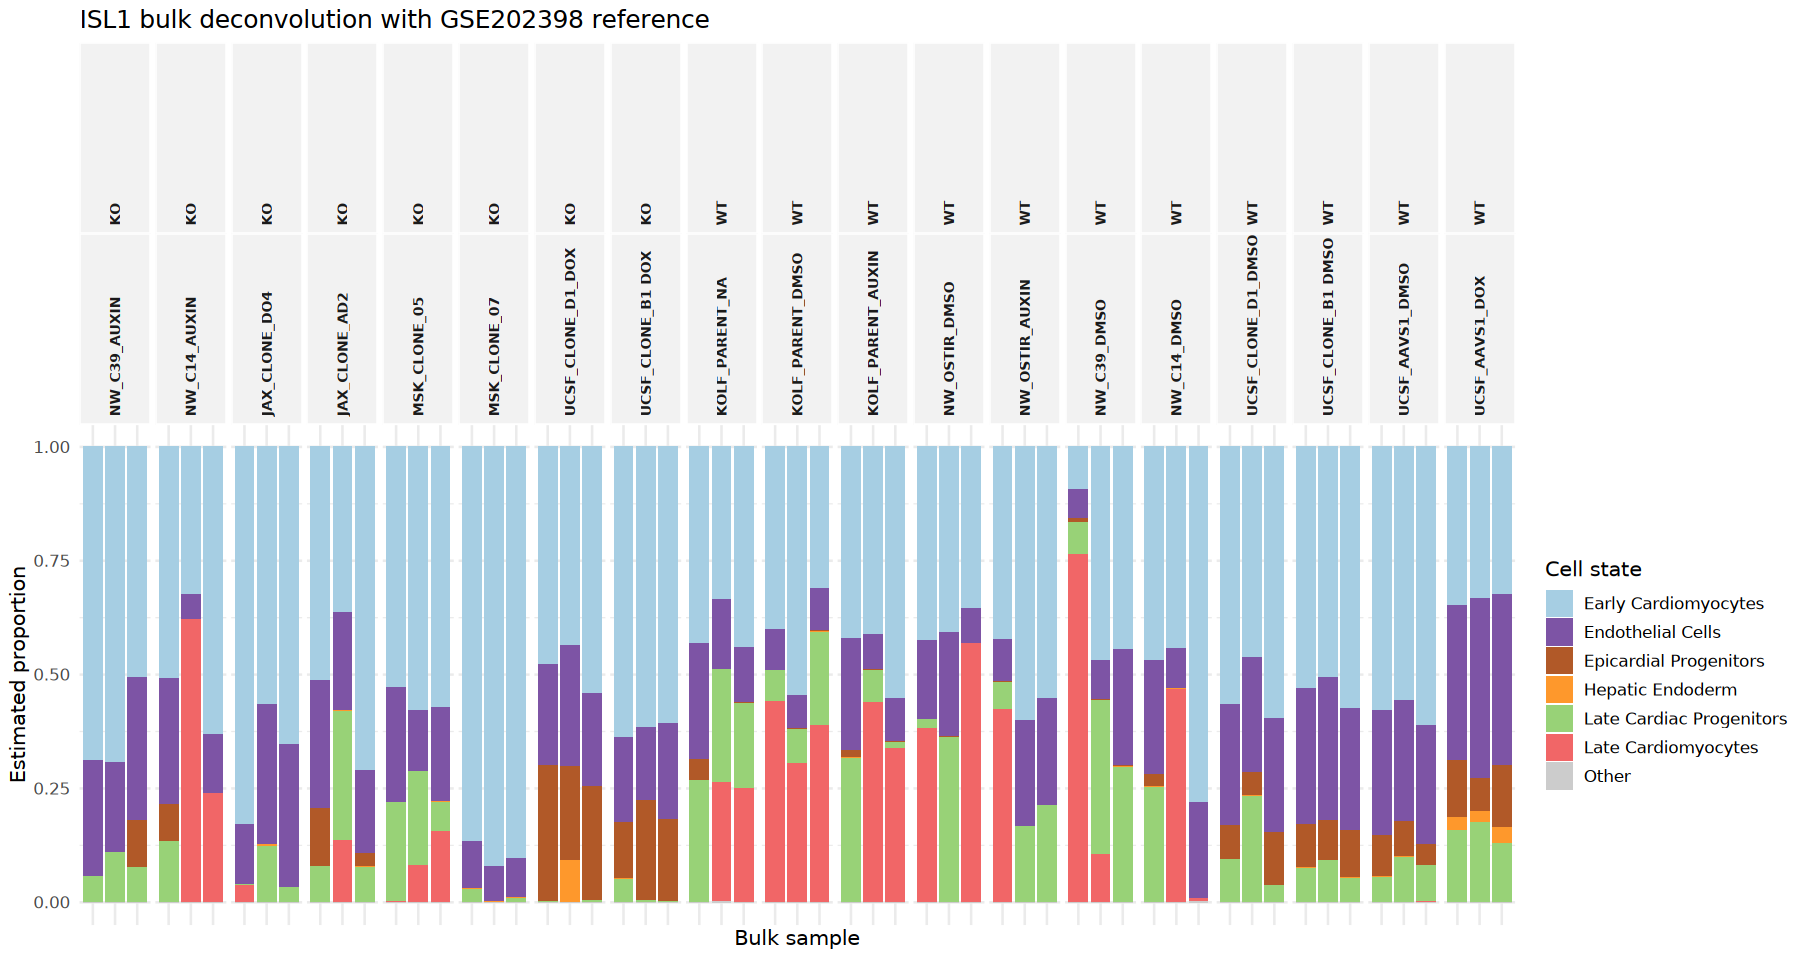

In [17]:
est_prop <- as.data.frame(music_results$Est.prop.weighted) %>%
  rownames_to_column(var = "SampleName")
cell_types <- setdiff(colnames(est_prop), "SampleName")

merged_data <- merge(est_prop, bulk_meta, by.x = "SampleName", by.y = "Name")

long_data <- merged_data %>%
  pivot_longer(
    cols = all_of(cell_types),
    names_to = "CellType",
    values_to = "Proportion"
  )

threshold <- 0.05
keep_cells <- long_data %>%
  group_by(CellType) %>%
  summarize(MaxProp = max(Proportion, na.rm = TRUE), .groups = "drop") %>%
  filter(MaxProp >= threshold) %>%
  pull(CellType)

long_data_clean <- long_data %>%
  mutate(CellType = if_else(CellType %in% keep_cells, CellType, "Other")) %>%
  group_by(SampleName, Dcondition, ko_gene, CellType) %>%
  summarize(Proportion = sum(Proportion, na.rm = TRUE), .groups = "drop")

label_map <- c(
  "UCSF_CLONE_D1_DOX"  = "UCSF CRISPRi sgRNA +Dox",
  "UCSF_CLONE_D1_DMSO" = "UCSF CRISPRi sgRNA +DMSO",
  "UCSF_CLONE_B1 DOX"  = "UCSF CRISPRi sgRNA +Dox",
  "UCSF_CLONE_B1 DMSO" = "UCSF CRISPRi sgRNA +DMSO",
  "UCSF_AAVS1_DMSO"    = "UCSF CRISPRi AAVS1 +DMSO",
  "UCSF_AAVS1_DOX"     = "UCSF CRISPRi AAVS1 +Dox",
  "NW_C14_AUXIN"       = "NW OsTIR Gene Tag +IAA",
  "NW_C39_AUXIN"       = "NW OsTIR Gene Tag +IAA",
  "NW_C39_DMSO"        = "NW OsTIR Gene Tag +DMSO",
  "NW_C14_DMSO"        = "NW OsTIR Gene Tag +DMSO",
  "NW_OSTIR_AUXIN"     = "NW OsTIR +IAA",
  "NW_OSTIR_DMSO"      = "NW OsTIR +DMSO",
  "JAX_CLONE_AD2"      = "JAX KO",
  "JAX_CLONE_DO4"      = "JAX KO",
  "MSK_CLONE_05"       = "MSK KO",
  "MSK_CLONE_07"       = "MSK KO",
  "KOLF_PARENT_NA"     = "KOLF parent"
)

plot_label <- label_map[long_data_clean$Dcondition]
plot_label[is.na(plot_label)] <- long_data_clean$Dcondition[is.na(plot_label)]
long_data_clean$plot_label <- plot_label

long_data_clean <- long_data_clean %>%
  mutate(
    ko_status = if_else(ko_gene == "WT", "WT", "KO"),
    ko_status = factor(ko_status, levels = c("KO", "WT")),
    Dcondition = factor(Dcondition, levels = unique(Dcondition)),
    plot_label = factor(plot_label, levels = unique(plot_label)),
    SampleName = factor(SampleName, levels = bulk_meta$Name[bulk_meta$Name %in% SampleName])
  )

n_colors <- length(setdiff(unique(long_data_clean$CellType), "Other"))
base_palette <- colorRampPalette(brewer.pal(12, "Paired"))(max(n_colors, 3))
set.seed(42)
distinct_colors <- sample(base_palette)[seq_len(n_colors)]
if ("Other" %in% unique(long_data_clean$CellType)) {
  final_colors <- c(setNames(distinct_colors, setdiff(unique(long_data_clean$CellType), "Other")), Other = "grey80")
} else {
  final_colors <- setNames(distinct_colors, unique(long_data_clean$CellType))
}

p_stacked <- ggplot(long_data_clean, aes(x = SampleName, y = Proportion, fill = CellType)) +
  geom_col(width = 0.85) +
  facet_grid(~ ko_status + Dcondition, scales = "free_x", space = "free_x") +
  scale_fill_manual(values = final_colors) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    strip.text.x = element_text(angle = 90, hjust = 0, vjust = 0.5, face = "bold", size = 8),
    panel.spacing = unit(0.2, "lines"),
    strip.background = element_rect(fill = "grey95", color = "white")
  ) +
  labs(
    title = "ISL1 bulk deconvolution with GSE202398 reference",
    x = "Bulk sample",
    y = "Estimated proportion",
    fill = "Cell state"
  )

print(p_stacked)


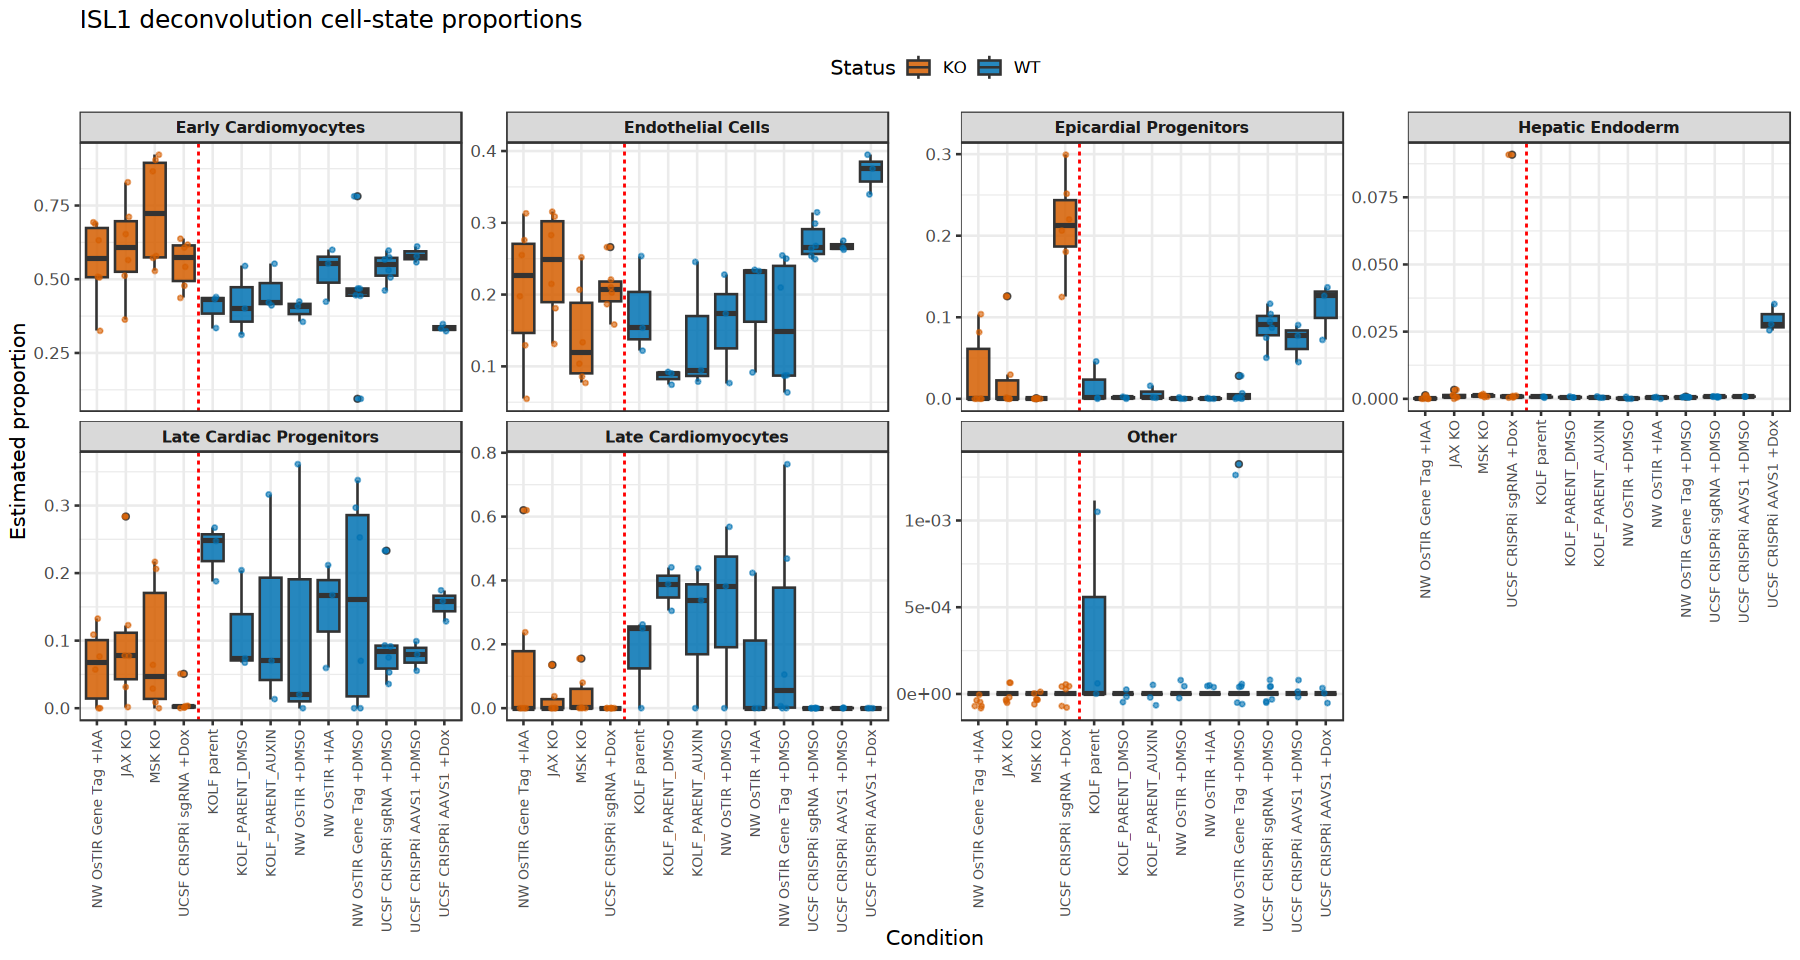

In [18]:
long_data_clean <- long_data_clean %>%
  mutate(
    ko_status = if_else(ko_gene == "WT", "WT", "KO"),
    ko_status = factor(ko_status, levels = c("KO", "WT"))
  )

plot_label_levels <- long_data_clean %>%
  distinct(plot_label, ko_status) %>%
  arrange(ko_status, plot_label) %>%
  pull(plot_label)

long_data_clean <- long_data_clean %>%
  mutate(plot_label = factor(plot_label, levels = plot_label_levels))

ko_plot_count <- length(unique(long_data_clean$plot_label[long_data_clean$ko_status == "KO"]))

p_box <- ggplot(long_data_clean, aes(x = plot_label, y = Proportion, fill = ko_status)) +
  geom_boxplot(outlier.shape = 21, outlier.size = 1.3, alpha = 0.85) +
  geom_jitter(aes(color = ko_status), width = 0.15, size = 0.8, alpha = 0.6, show.legend = FALSE) +
  geom_vline(xintercept = ko_plot_count + 0.5, linetype = "dashed", color = "red", linewidth = 0.6) +
  facet_wrap(~ CellType, scales = "free_y", ncol = 4) +
  scale_fill_manual(values = c(KO = "#D55E00", WT = "#0072B2")) +
  scale_color_manual(values = c(KO = "#D55E00", WT = "#0072B2")) +
  theme_bw(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    strip.text = element_text(face = "bold", size = 9),
    legend.position = "top"
  ) +
  labs(
    title = "ISL1 deconvolution cell-state proportions",
    x = "Condition",
    y = "Estimated proportion",
    fill = "Status"
  )

print(p_box)

## Quick checks

These tables confirm which eLife marker labels were assigned to the generated Leiden clusters and whether the final proportions sum as expected.


In [19]:
cell_count_table <- as.data.frame(table(sc_ref$cell_type_music, sc_ref$sample_id)) %>%
  setNames(c("CellType", "ReferenceSample", "N")) %>%
  arrange(CellType, ReferenceSample)

print(cell_count_table %>% group_by(CellType) %>% summarize(total_cells = sum(N), .groups = "drop"))

if (exists("long_data")) {
  prop_check <- long_data %>%
    group_by(SampleName) %>%
    summarize(total_prop = sum(Proportion, na.rm = TRUE), n_missing = sum(is.na(Proportion)), .groups = "drop")
  print(prop_check)
}


# A tibble: 13 × 2
   CellType                  total_cells
   <fct>                           <int>
 1 Early Primitive Streak           4427
 2 Epicardial Progenitors           5425
 3 Hepatic Endoderm                 3225
 4 Definitive Endoderm                 0
 5 Early Cardiac Progenitors        2143
 6 Late Primitive Streak               0
 7 Mesodermal Progenitors              0
 8 Pluripotent Stem Cells           4740
 9 Epicardial Cells                 1531
10 Late Cardiac Progenitors          876
11 Endothelial Cells                 430
12 Early Cardiomyocytes             7031
13 Late Cardiomyocytes              1733
# A tibble: 57 × 3
   SampleName    total_prop n_missing
   <chr>              <dbl>     <int>
 1 23247XR-05-01          1         0
 2 23247XR-05-02          1         0
 3 23247XR-05-03          1         0
 4 23247XR-05-04          1         0
 5 23247XR-05-05          1         0
 6 23247XR-05-06          1         0
 7 23247XR-05-07          1         0
 8 23

In [20]:
sessionInfo()


R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /home/sshen2/.conda/envs/r/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] MuSiC_1.0.0                 TOAST_1.24.0               
 [3] quadprog_1.5-8              limma_3.66.0               
 [5] EpiDISH_2.26.0              nnls_1.6                   
 [7] future_1.70.0               RColorBrewer_1.1-3         
 [9] ggplot2_4.0.3               str